In [1]:
import pandas as pd
import plotly.express as px
import numpy as np

In [2]:
import pandas as pd
import plotly.express as px

df = pd.read_csv(
    r"C:\Users\Administrator\Desktop\data-viz-class-material\data\airbnb_london.csv"
)

print(df.shape)
df.head()

(2500, 7)


,neighbourhood,room_type,price,minimum_nights,number_of_reviews,availability_365,reviews_per_month
0,Hammersmith,Entire home/apt,148.55,6,158,302,3.75
1,Kensington and Chelsea,Private room,393.56,29,46,323,2.56
2,Camden,Entire home/apt,197.64,19,242,291,2.52
3,Southwark,Private room,70.47,6,199,22,1.24
4,Hammersmith,Private room,96.58,18,110,103,4.11


In [3]:
print(df.columns.tolist())

['neighbourhood', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'availability_365', 'reviews_per_month']


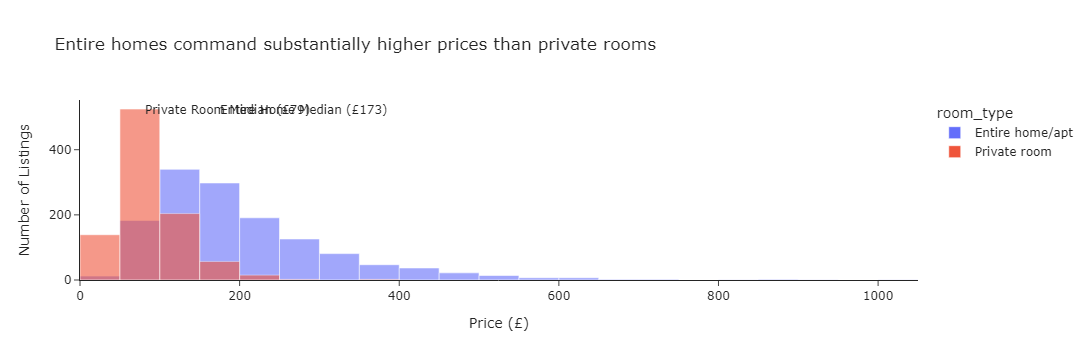

In [4]:
# Task 1

hist_df = df[
    df['room_type'].isin(['Entire home/apt', 'Private room'])
]

fig = px.histogram(
    hist_df,
    x='price',
    color='room_type',
    barmode='overlay',
    opacity=0.6,
    nbins=40,
    title='Entire homes command substantially higher prices than private rooms'
)

entire_median = hist_df.loc[
    hist_df['room_type'] == 'Entire home/apt',
    'price'
].median()

private_median = hist_df.loc[
    hist_df['room_type'] == 'Private room',
    'price'
].median()

fig.add_vline(
    x=entire_median,
    line_dash='dash',
    annotation_text=f'Entire Home Median (£{entire_median:.0f})'
)

fig.add_vline(
    x=private_median,
    line_dash='dot',
    annotation_text=f'Private Room Median (£{private_median:.0f})'
)

fig.update_layout(
    xaxis_title='Price (£)',
    yaxis_title='Number of Listings',
    template='simple_white'
)

fig.show()

In [10]:
print(df.columns.tolist())
for col in df.columns:
    print(col)

['neighbourhood', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'availability_365', 'reviews_per_month']
neighbourhood
room_type
price
minimum_nights
number_of_reviews
availability_365
reviews_per_month


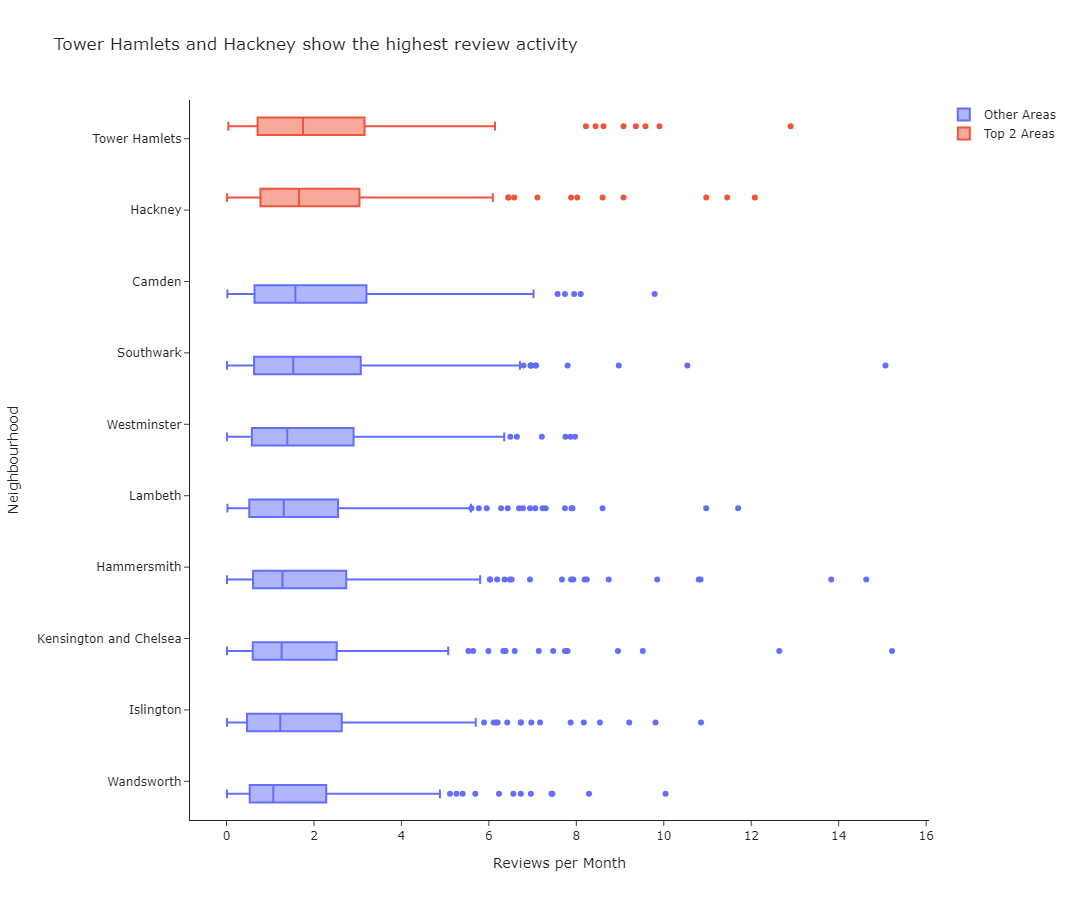

In [12]:
# Task 2

active_df = df[df['reviews_per_month'] > 0].copy()

# Calculate median reviews by neighbourhood
neighbourhood_order = (
    active_df.groupby('neighbourhood')['reviews_per_month']
    .median()
    .sort_values(ascending=False)
)

# Top 2 neighbourhoods
top_two = neighbourhood_order.head(2).index.tolist()

# Highlight top 2
active_df['highlight'] = active_df['neighbourhood'].apply(
    lambda x: 'Top 2 Areas' if x in top_two else 'Other Areas'
)

fig = px.box(
    active_df,
    x='reviews_per_month',
    y='neighbourhood',
    color='highlight',
    points='outliers',
    orientation='h',
    category_orders={
        'neighbourhood': neighbourhood_order.index.tolist()
    },
    title=f'{top_two[0]} and {top_two[1]} show the highest review activity'
)

fig.update_layout(
    template='simple_white',
    xaxis_title='Reviews per Month',
    yaxis_title='Neighbourhood',
    legend_title='',
    height=900
)

fig.show()